# M1.Ex4: Modeling Non-linear Patterns

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex4_non-linear.ipynb)
- Raw Dataset: [bmi_and_life_expectancy.csv](https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/bmi_and_life_expectancy.csv)

In [105]:
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

### Step 1. Load the data


In [106]:
df=pd.read_csv("bmi_and_life_expectancy.csv")
df.head()

,Country,Life expectancy,BMI
0,Afghanistan,52.8,20.62058
1,Albania,76.8,26.44657
2,Algeria,75.5,24.59620
3,Andorra,84.6,27.63048
4,Angola,56.7,22.25083


### Step 2.a Assign variables `X` to the features and `y` to the target

In [107]:
X = df[['BMI']]
y = df['Life expectancy']

### Step 2.b print the type of each

In [108]:
print(type(X))
print(type(y))

<class 'pandas.DataFrame'>
<class 'pandas.Series'>


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [141]:
#Target is numerical, so this is a regression task.

### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [140]:
print(X.shape)
print(y.shape)

(163, 1)
(163,)


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [109]:
df.describe()

,Life expectancy,BMI
count,163.000000,163.000000
mean,69.666933,24.792378
std,8.981933,2.427900
min,44.500000,19.866920
25%,63.450000,22.527940
50%,71.800000,25.320540
75%,76.500000,26.603960
max,84.600000,30.995630


### Step 5. Plot the feature vs the target

<Axes: xlabel='BMI', ylabel='Life expectancy'>

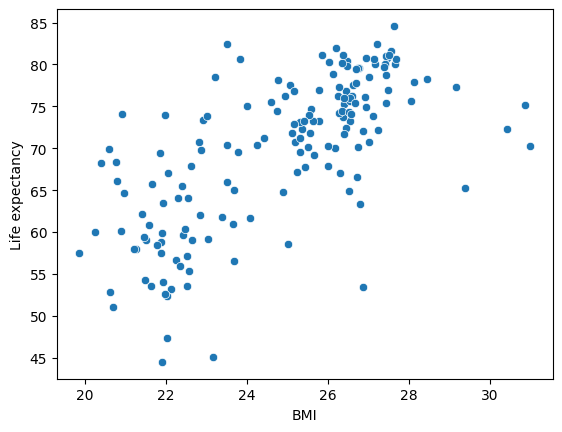

In [110]:
sns.scatterplot(data= df, x="BMI", y="Life expectancy")

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

In [137]:
#it increases but not in a linear way, it seems to be more of a curve

### Step 7. Make two modeling techniques

First model is just a Linear Regression model: `from sklearn.linear_model import LinearRegression`

Second model: Use one of the previously mentioned methods to model a non-linear relationship

1. `from sklearn.tree import DecisionTreeRegressor`
2. or `from sklearn.preprocessing import PolynomialFeatures`

In [117]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

lin_model = LinearRegression()

poly_model = make_pipeline(PolynomialFeatures(degree=2, include_bias=False), LinearRegression())


### Step 8. Split the dataset into train and test sets

In [118]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Step 9. Train both models on the training set

In [119]:
lin_model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [120]:
poly_model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('polynomialfeatures', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06


### Step 10. Evaluate and compare which of the two models score better on the `train` set

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
y_pred = lin_model.predict(X_train)
print(f"R2: {r2_score(y_train, y_pred):.2%}")
print(f"MAE: {mean_absolute_error(y_train, y_pred):.2%}")
print(f"MSE: {mean_squared_error(y_train, y_pred):.2%}")

y_pred_poly = poly_model.predict(X_train)
print(f"R2: {r2_score(y_train, y_pred_poly):.2%}")
print(f"MAE: {mean_absolute_error(y_train, y_pred_poly):.2%}")
print(f"MSE: {mean_squared_error(y_train, y_pred_poly):.2%}")
# #from the above we can see that they are close but ploynomial is a little better  int the train 

R2: 49.40%
MAE: 485.05%
MSE: 3966.71%
R2: 51.44%
MAE: 471.90%
MSE: 3806.45%


### Step 11. Evaluate and compare which of the two models score better on the `test` set

In [ ]:
y_pred = lin_model.predict(X_test)
print(f"R2: {r2_score(y_test, y_pred):.2%}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2%}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.2%}")
print(30*'-')
y_pred_poly = poly_model.predict(X_test)
print(f"R2: {r2_score(y_test, y_pred_poly):.2%}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_poly):.2%}")
print(f"MSE: {mean_squared_error(y_test, y_pred_poly):.2%}")

#from the above we can see that polynomial preforms better than liner in the test 

R2: 35.40%
MAE: 600.62%
MSE: 5633.17%
------------------------------
R2: 40.31%
MAE: 571.00%
MSE: 5205.12%
